# NVIDIA Earth-2 Studio — a beginner's tutorial

### Smithsonian **Living Earth Digital Twin** · Innovation Workshop, SAO Cambridge, Sept 14–16 2026

---

Welcome. By the end of this notebook you will have:

1. run a **real AI weather forecast** with NVIDIA's [Earth2Studio](https://github.com/NVIDIA/earth2studio),
2. looked at a slice of **NASA TEMPO** NO₂ data (the SAO-led geostationary air-quality instrument),
3. **written your own Earth-2 "diagnostic model"** — about 40 lines of PyTorch — and
4. **plugged it into the forecast pipeline**, which is exactly the mechanism the LEDT proposes to use
   to bolt an ecological feedback layer onto a planetary digital twin.

You do **not** need to know PyTorch. You do **not** need to know anything about Earth-2. You need to
be able to read Python and press <kbd>Shift</kbd>+<kbd>Enter</kbd>.

> **This is a tutorial, not a result.** Nothing in here is science. The ecological response model at the
> end is deliberately a toy — API scaffolding so that the whole pipeline runs end to end. Building the
> real thing is what the workshop is for.

## How to use this notebook

**Run every cell in order, top to bottom** (<kbd>Shift</kbd>+<kbd>Enter</kbd>, or *Run ▸ Run All Cells*).
Cells depend on the ones above them.

### It runs in three different places, and adapts itself

| Where you are | What the notebook calls it | What actually happens |
|---|---|---|
| The workshop GPU hub (or any NVIDIA GPU box) | 🟢 **`gpu`** | Real Earth2Studio, real model weights, real forecast on the GPU |
| Your laptop, with `earth2studio` installed | 🟡 **`cpu`** | Real Earth2Studio API and real GFS data, but a trivial model — no big weights, no GPU |
| Your laptop, with nothing installed but this repo | 💻 **`dry`** | A small stand-in that mimics the Earth2Studio API so every cell still runs and plots |

You don't have to choose — the next cell works out which one you're in. **A MacBook with no NVIDIA GPU
will run this whole notebook happily**; the plots will be labelled `SIMULATED` where the real thing
would have needed a GPU, so you can see the shape of the workflow before you get to the hub.

If you want to *deliberately* see the laptop experience while sitting on the GPU hub, run this in a
cell before Step 1 and restart:

```python
import os; os.environ["LEDT_MODE"] = "dry"
```

### How long does it take?

- 💻 `dry` / 🟡 `cpu`: about **5 minutes**, mostly reading.
- 🟢 `gpu`: about **15 minutes** the first time — the model weights (a few hundred MB) download once
  and are then cached in `~/.cache/earth2studio`.

### If something breaks

Skip to **[Appendix A · Troubleshooting](#appendix-a--troubleshooting)** at the bottom. Every step is
wrapped so that a network hiccup degrades to the simulated path instead of stopping the notebook.

---

## Step 1 · Where am I running?

This cell doesn't download anything or import anything heavy. It just looks around and decides which
of the three modes above applies, then prints a summary.

The three things it checks:

- **`torch`** — PyTorch, the deep-learning library everything here is built on.
- **`torch.cuda.is_available()`** — the standard "do I have a usable NVIDIA GPU?" test. This is `False`
  on every Mac; Apple Silicon has a GPU, but not a *CUDA* GPU, and Earth-2's models are CUDA-only.
- **`earth2studio`** — NVIDIA's package itself.

In [1]:
# --- Step 1 · environment check -------------------------------------------
import importlib.util
import os
import platform
import shutil
import subprocess
import sys


def have(module: str) -> bool:
    """True if `module` can be imported, without actually importing it."""
    try:
        return importlib.util.find_spec(module) is not None
    except (ImportError, ValueError):
        return False


HAVE_TORCH = have("torch")
HAVE_E2S = have("earth2studio")
HAVE_CUDA, GPU_NAME, GPU_MEM_GB = False, None, None

if HAVE_TORCH:
    import torch

    HAVE_CUDA = torch.cuda.is_available()
    if HAVE_CUDA:
        props = torch.cuda.get_device_properties(0)
        GPU_NAME = props.name
        GPU_MEM_GB = props.total_memory / 1024**3

# You can override the auto-detection: os.environ["LEDT_MODE"] = "dry"
_forced = os.environ.get("LEDT_MODE", "").strip().lower()
if _forced in {"gpu", "cpu", "dry"}:
    MODE = _forced
elif HAVE_E2S and HAVE_CUDA:
    MODE = "gpu"
elif HAVE_E2S:
    MODE = "cpu"
else:
    MODE = "dry"

BLURB = {
    "gpu": "Real Earth2Studio inference on a real NVIDIA GPU. Everything below is the real thing.",
    "cpu": "Real Earth2Studio API and real GFS data, but on CPU with a trivial model. "
           "The heavy AI forecast will be simulated.",
    "dry": "No earth2studio installed — the notebook will stand in for it so every cell still "
           "runs and plots. Perfect for reading through on a laptop.",
}
ICON = {"gpu": "\N{LARGE GREEN CIRCLE}", "cpu": "\N{LARGE YELLOW CIRCLE}", "dry": "\N{PERSONAL COMPUTER}"}


def box(title: str, lines: list[str], width: int = 78) -> None:
    """Print a plain-text box. Purely cosmetic."""
    import unicodedata

    def cells(text: str) -> int:  # emoji occupy two terminal columns
        return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1 for c in text)

    def pad(text: str) -> str:
        return text + " " * max(0, (width - 4) - cells(text))

    print("┌" + "─" * (width - 2) + "┐")
    print("│ " + pad(title) + " │")
    print("├" + "─" * (width - 2) + "┤")
    for line in lines:
        while cells(line) > width - 4:
            cut = line.rfind(" ", 0, width - 4) or (width - 4)
            print("│ " + pad(line[:cut]) + " │")
            line = "  " + line[cut:].lstrip()
        print("│ " + pad(line) + " │")
    print("└" + "─" * (width - 2) + "┘")


box(
    f"{ICON[MODE]}  MODE = {MODE!r}",
    [
        BLURB[MODE],
        "",
        f"python            {platform.python_version()}  ({platform.system()} {platform.machine()})",
        f"torch installed   {HAVE_TORCH}" + (f"  (v{torch.__version__})" if HAVE_TORCH else ""),
        f"CUDA GPU visible  {HAVE_CUDA}"
        + (f"  → {GPU_NAME}, {GPU_MEM_GB:.0f} GB" if HAVE_CUDA else ""),
        f"earth2studio      {HAVE_E2S}",
    ],
)

# The classic sanity check. On the workshop hub this is your proof the GPU is really there.
if shutil.which("nvidia-smi"):
    print()
    print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)
else:
    print("\n(no `nvidia-smi` on this machine — expected on a Mac)")

┌────────────────────────────────────────────────────────────────────────────┐
│ 💻  MODE = 'dry'                                                           │
├────────────────────────────────────────────────────────────────────────────┤
│ No earth2studio installed — the notebook will stand in for it so every     │
│   cell still runs and plots. Perfect for reading through on a laptop.      │
│                                                                            │
│ python            3.12.3  (Linux x86_64)                                   │
│ torch installed   True  (v2.11.0+cu130)                                    │
│ CUDA GPU visible  False                                                    │
│ earth2studio      False                                                    │
└────────────────────────────────────────────────────────────────────────────┘

(no `nvidia-smi` on this machine — expected on a Mac)


**What you should see.** A box telling you which mode you're in.

- On the workshop hub: `MODE = 'gpu'`, plus the `nvidia-smi` table showing a GPU (an L4, A100 or
  similar) with almost no memory in use. That table *is* the acceptance test for the hosted
  environment — if you can see it, the GPU is wired through to your notebook correctly.
- On your Mac: `MODE = 'dry'` (or `'cpu'` if you installed earth2studio) and a note that there's no
  `nvidia-smi`. That's fine and expected. Keep going.

---

## Step 2 · Installing Earth2Studio (and why it's fussy)

**On the workshop hub, skip this — it's already installed.** This section is here so you can
reproduce the environment on your own machine or a cloud box afterwards.

Earth2Studio has a small core and a *lot* of optional pieces, because every weather model it wraps
drags in its own dependencies. So you install it with **extras** — the bracket list — naming only the
models you actually want:

```bash
# the two models this tutorial uses, plus the data-source extras
pip install "earth2studio[fcn,precip-afno,data]==0.17.0"
```

`uv` works too, and is what NVIDIA recommends:

```bash
uv add "earth2studio[fcn,precip-afno,data]==0.17.0"
```

A few things worth knowing before you burn an afternoon on it:

- **Install PyTorch first**, matched to your CUDA version, using the
  [official selector](https://pytorch.org/get-started/locally/). Most Earth2Studio install failures
  are really PyTorch/CUDA mismatches.
- **Python 3.11–3.14.** NVIDIA recommends 3.13; this repo pins 3.12 and that's fine.
- **Some extras need a GPU present at install time** (a couple compile CUDA kernels). `fcn` and
  `precip-afno` — the ones used here — only need `nvidia-physicsnemo` and install cleanly.
- **Model weights are not in the package.** They download on first use from NVIDIA NGC / Hugging Face
  into `~/.cache/earth2studio` (override with `EARTH2STUDIO_CACHE`). Budget a few hundred MB per model.
- **Don't add earth2studio to this repo's `pyproject.toml`.** It's GPU-only; this repo's environment is
  deliberately CPU-only so the notebooks stay runnable on a laptop.

### Hardware, honestly

NVIDIA's stated baseline for Earth2Studio is a GPU with **compute capability ≥ 8.9** (L40S, A6000,
H100…) and **≥ 40 GB** of memory, with ~128 GB of disk for cached weights. Their docs say *"if PyTorch
can run, many features of Earth2Studio should run as well"* — which is true, and is not the same
sentence as *"runs well."* Smaller models such as the one used here are much less demanding than that
baseline; the giant ensembles are much more.

The cell below just tells you what you've got. It won't install anything.

In [2]:
# --- Step 2 · what's installed --------------------------------------------
if HAVE_E2S:
    import earth2studio

    print(f"earth2studio {earth2studio.__version__} is installed \N{WHITE HEAVY CHECK MARK}")
    print(f"model + data cache: {os.environ.get('EARTH2STUDIO_CACHE', '~/.cache/earth2studio')}")
else:
    print("earth2studio is NOT installed — running in dry-run mode.")
    print("Nothing to do: every cell below has a stand-in. To install it later:\n")
    print('    pip install "earth2studio[fcn,precip-afno,data]==0.17.0"')

earth2studio is NOT installed — running in dry-run mode.
Nothing to do: every cell below has a stand-in. To install it later:

    pip install "earth2studio[fcn,precip-afno,data]==0.17.0"


---

## Step 3 · The mental model: four Lego bricks

This is the single most useful thing to understand, and it takes two minutes.

Earth2Studio is not one program. It's a set of interchangeable components with agreed-upon plug
shapes, plus a couple of functions that snap them together:

```
      ┌──────────────┐        ┌────────────────┐        ┌────────────────┐        ┌────────────┐
      │ DATA SOURCE  │───────▶│   PROGNOSTIC   │───────▶│   DIAGNOSTIC   │───────▶│ IO BACKEND │
      │              │        │     MODEL      │        │     MODEL      │        │            │
      │ GFS, ERA5,   │        │ FourCastNet,   │        │ precipitation, │        │ Zarr,      │
      │ HRRR, IFS,   │        │ GraphCast,     │        │ CorrDiff,      │        │ NetCDF,    │
      │ GOES, CMIP6  │        │ Aurora, SFNO   │        │ *your own*     │        │ xarray     │
      └──────────────┘        └────────────────┘        └────────────────┘        └────────────┘
        "what was the           "what happens             "what else can            "where do the
         atmosphere              next?"                    I derive from             numbers go?"
         doing?"                                           that state?"
```

| Brick | Import | In one sentence |
|---|---|---|
| **Data source** | `earth2studio.data` | Fetches the initial condition — the state of the atmosphere at some past moment. |
| **Prognostic model** (`px`) | `earth2studio.models.px` | Steps that state *forward in time*. This is the AI weather model. |
| **Diagnostic model** (`dx`) | `earth2studio.models.dx` | Derives *another quantity* from a state, without stepping time. |
| **IO backend** | `earth2studio.io` | Writes results to Zarr / NetCDF / memory. |
| **Workflow** | `earth2studio.run` | `deterministic`, `diagnostic`, `ensemble` — one-line drivers that wire the bricks together. |

**Prognostic vs diagnostic** is the distinction to hold onto:

- A **prognostic** model advances time. `FCN` takes the atmosphere now and gives you the atmosphere in
  6 hours.
- A **diagnostic** model doesn't. It takes a state and returns something *else* about that same
  moment — total precipitation, hurricane tracks, a downscaled km-scale field.

**This is where the Living Earth Digital Twin plugs in.** Earth-2, DestinE and NASA's ESDT all model
the atmosphere superbly and treat the biosphere as a fixed boundary condition. A *diagnostic* is
exactly the socket for "given this atmospheric state, what is the ecosystem doing?" You will write one
in Step 8.

The next cell prints what's actually available in your installed version. In dry-run mode it prints a
short curated list instead.

In [3]:
# --- Step 3 · what components exist ---------------------------------------
if HAVE_E2S:
    import earth2studio.data as e2s_data
    import earth2studio.io as e2s_io
    import earth2studio.models.dx as dx
    import earth2studio.models.px as px

    def public(module):
        return sorted(n for n in dir(module) if n[0].isupper() and not n.startswith("_"))

    print(f"Prognostic models ({len(public(px))}):\n  ", ", ".join(public(px)), "\n")
    print(f"Diagnostic models ({len(public(dx))}):\n  ", ", ".join(public(dx)), "\n")
    print(f"IO backends:\n  ", ", ".join(public(e2s_io)), "\n")
    print(f"Data sources ({len(public(e2s_data))}):\n  ", ", ".join(public(e2s_data)[:40]), "...")
else:
    print("A sampler of what's in the catalogue (v0.17):\n")
    print("  prognostic  FCN, FCN3, SFNO, DLWP, Pangu3/6/24, GraphCastSmall, Aurora,")
    print("              AIFS, FengWu, FuXi, StormCast, CBottleVideo, Persistence")
    print("  diagnostic  PrecipitationAFNO, CorrDiff, ClimateNet, WindgustAFNO,")
    print("              SolarRadiationAFNO, CBottleSR, TCTracker, Identity")
    print("  data        GFS, ARCO (ERA5), HRRR, IFS, CDS, GOES, CMIP6, WB2ERA5, Random")
    print("  io          ZarrBackend, AsyncZarrBackend, NetCDF4Backend, XarrayBackend, KVBackend")
    print("\nFull, current catalogue: https://nvidia.github.io/earth2studio")

A sampler of what's in the catalogue (v0.17):

  prognostic  FCN, FCN3, SFNO, DLWP, Pangu3/6/24, GraphCastSmall, Aurora,
              AIFS, FengWu, FuXi, StormCast, CBottleVideo, Persistence
  diagnostic  PrecipitationAFNO, CorrDiff, ClimateNet, WindgustAFNO,
              SolarRadiationAFNO, CBottleSR, TCTracker, Identity
  data        GFS, ARCO (ERA5), HRRR, IFS, CDS, GOES, CMIP6, WB2ERA5, Random
  io          ZarrBackend, AsyncZarrBackend, NetCDF4Backend, XarrayBackend, KVBackend

Full, current catalogue: https://nvidia.github.io/earth2studio


---

## Step 4 · Coordinates — the one concept you have to get right

Every model in Earth2Studio describes itself with a **coordinate system**: an `OrderedDict` mapping
each dimension name to the array of values along it. Two methods on every model:

- `model.input_coords()` — "here is exactly the shape of data I accept"
- `model.output_coords(input_coords)` — "and here is what I'll hand back"

That's the whole contract. A typical one looks like:

```python
OrderedDict({
    "batch":    np.empty(0),                              # placeholder — any batch size
    "variable": np.array(["u10m", "v10m", "t2m", ...]),   # which physical fields
    "lat":      np.linspace(90, -90, 720, endpoint=False),
    "lon":      np.linspace(0, 360, 1440, endpoint=False),
})
```

Three rules that will save you an hour of confusion:

1. **The order of keys is the order of the tensor axes.** The dict above describes a tensor of shape
   `(batch, variable, lat, lon)`. Not a convention — a hard requirement.
2. **Latitude runs north to south** (`+90 → −90`) and **longitude runs 0 → 360**, not −180 → 180.
   Nearly every "my map is upside down / shifted by half a world" bug is one of these two.
3. **Grids must match to connect two models.** Earth2Studio checks this for you at runtime with
   "handshake" helpers, and raises a clear error rather than silently interpolating. Note that
   different models genuinely use different grids: `FCN` uses **720** latitudes
   (`endpoint=False`, so no south pole), while `SFNO`, `DLWP` and `FCN3` use **721** (pole to pole).
   Mixing them up is the second most common beginner error.

`batch` is a placeholder dimension — `np.empty(0)` means "I don't care how many". Earth2Studio's
`@batch_func()` decorator handles reshaping for you.

The cell below builds one by hand so you can see the shapes line up. Pure NumPy — no GPU, no
earth2studio needed.

In [4]:
# --- Step 4 · coordinates by hand -----------------------------------------
from collections import OrderedDict

import numpy as np

# The standard Earth-2 quarter-degree global grid used by FourCastNet (FCN).
E2_LAT = np.linspace(90, -90, 720, endpoint=False)   # north -> south, no south pole
E2_LON = np.linspace(0, 360, 1440, endpoint=False)   # 0 -> 360, no duplicate at 360

example_coords = OrderedDict(
    {
        "batch": np.empty(0),
        "variable": np.array(["t2m"]),
        "lat": E2_LAT,
        "lon": E2_LON,
    }
)

print("dimension    length   first        last")
print("-" * 46)
for name, values in example_coords.items():
    if values.size == 0:
        print(f"{name:<12} {'(any)':>6}")
    else:
        print(f"{name:<12} {values.size:>6}   {str(values[0]):<12} {values[-1]}")

print(f"\nGrid spacing: {abs(E2_LAT[1] - E2_LAT[0]):.2f}° lat, "
      f"{E2_LON[1] - E2_LON[0]:.2f}° lon  (~25 km at the equator)")
print(f"A tensor on these coords has shape (batch, 1, {E2_LAT.size}, {E2_LON.size})")
print(f"= {E2_LAT.size * E2_LON.size:,} grid cells per variable per timestep.")

dimension    length   first        last
----------------------------------------------
batch         (any)
variable          1   t2m          t2m
lat             720   90.0         -89.75
lon            1440   0.0          359.75

Grid spacing: 0.25° lat, 0.25° lon  (~25 km at the equator)
A tensor on these coords has shape (batch, 1, 720, 1440)
= 1,036,800 grid cells per variable per timestep.


---

## Step 5 · A plotting helper

Nothing conceptual here — just one function we'll reuse for every map, so the rest of the notebook
stays readable. It uses [Cartopy](https://scitools.org.uk/cartopy/) for coastlines if you have it and
falls back to a plain image if you don't. **You can skip reading this cell.**

(The first map you draw may pause for a few seconds while Cartopy downloads Natural Earth coastline
files and prints a `DownloadWarning`. That's normal, happens once, and is cached afterwards.)

In [5]:
# --- Step 5 · one plotting helper, reused everywhere -----------------------
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    HAVE_CARTOPY = True
except Exception:
    HAVE_CARTOPY = False

INK, PAPER = "#e7ecf7", "#05070d"


def plot_field(
    values,
    lats,
    lons,
    title="",
    units="",
    cmap="magma",
    extent=None,
    watermark=None,
    vmin=None,
    vmax=None,
):
    """Draw a 2-D lat/lon field. `lons` may be 0..360 or -180..180."""
    values = np.asarray(values, dtype=float)
    lons = np.asarray(lons, dtype=float)
    lats = np.asarray(lats, dtype=float)

    # Matplotlib/Cartopy are happier with -180..180; roll the array if needed.
    if lons.max() > 180:
        shift = np.argmax(lons >= 180)
        lons = np.concatenate([lons[shift:] - 360, lons[:shift]])
        values = np.concatenate([values[:, shift:], values[:, :shift]], axis=1)

    if vmin is None:
        vmin = np.nanpercentile(values, 1)
    if vmax is None:
        vmax = np.nanpercentile(values, 99)

    # Missing data (NaN) gets its own colour so "no observation" never reads
    # as "a low value" — an easy and expensive mistake with satellite data.
    shades = plt.get_cmap(cmap).copy()
    shades.set_bad("#252c3d")

    fig = plt.figure(figsize=(11, 5.2), facecolor=PAPER)
    if HAVE_CARTOPY:
        ax = plt.axes(projection=ccrs.PlateCarree())
        mesh = ax.pcolormesh(
            lons, lats, values, cmap=shades, vmin=vmin, vmax=vmax,
            transform=ccrs.PlateCarree(), shading="auto",
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#9fb4d8", zorder=5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="#64738f", zorder=5)
        if extent:
            ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.gridlines(linewidth=0.2, color="#2a3550", draw_labels=False)
    else:
        ax = plt.axes()
        mesh = ax.pcolormesh(lons, lats, values, cmap=shades, vmin=vmin, vmax=vmax, shading="auto")
        if extent:
            ax.set_xlim(extent[0], extent[1])
            ax.set_ylim(extent[2], extent[3])
        ax.set_xlabel("longitude", color=INK)
        ax.set_ylabel("latitude", color=INK)
        ax.tick_params(colors=INK)

    ax.set_facecolor(PAPER)
    ax.set_title(title, color=INK, fontsize=12, pad=10)
    cbar = plt.colorbar(mesh, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label(units, color=INK)
    cbar.ax.yaxis.set_tick_params(color=INK)
    cbar.ax.yaxis.get_offset_text().set_color(INK)
    plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color=INK)

    if watermark:
        ax.text(
            0.5, 0.5, watermark, transform=ax.transAxes, ha="center", va="center",
            fontsize=34, color="#ffffff", alpha=0.16, weight="bold", rotation=18, zorder=99,
        )
    plt.tight_layout()
    plt.show()


print("plot_field() ready.  cartopy coastlines:", HAVE_CARTOPY)

plot_field() ready.  cartopy coastlines: True


---

## Step 6 · Your first forecast

Here is the entire program, in the real Earth2Studio API:

```python
from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
from earth2studio.models.px import FCN
import earth2studio.run as run

model = FCN.load_model(FCN.load_default_package())   # download + load weights
io = run.deterministic(["2024-01-01"], 4, model, GFS(), ZarrBackend())
```

Five lines. Read them as English:

1. `FCN.load_default_package()` — go get the official FourCastNet checkpoint (cached after the first
   time).
2. `FCN.load_model(package)` — build the PyTorch model from it.
3. `GFS()` — NOAA's Global Forecast System analysis, used here purely as the *initial condition*: the
   observed state of the atmosphere at the start time.
4. `ZarrBackend()` — collect the output in memory as a Zarr store. Pass a path to write to disk.
5. `run.deterministic(time, nsteps, model, data, io)` — roll it forward `nsteps` model steps. FCN's
   step is 6 hours, so `nsteps=4` is a 24-hour forecast.

That's *the* Earth2Studio idiom. Almost everything else is a variation on it.

### What actually happens in each mode

- 🟢 **`gpu`** — exactly the code above. First run downloads the FCN checkpoint (a few hundred MB) and
  a GFS snapshot; expect a couple of minutes, then a progress bar.
- 🟡 **`cpu`** — the same `run.deterministic` call and the same real GFS data, but with
  `Persistence` as the model: a trivial "prognostic" that just repeats the initial condition forward.
  It is a real Earth2Studio model implementing the real interface, and it runs fine on a laptop. You
  get a genuine end-to-end run; you just don't get a forecast.
- 💻 **`dry`** — a stand-in object that produces a smooth analytic field drifting eastward. It is
  **not** weather and every plot from it is stamped `SIMULATED`. Its only job is to have the same
  shape as a `ZarrBackend` so the rest of the notebook runs unchanged.

A useful thing to notice: `run.deterministic` is device-agnostic. It calls
`torch.device("cuda" if torch.cuda.is_available() else "cpu")` and gets on with it. Downloading data is
device-agnostic too. **Only the big model's arithmetic actually needs the GPU** — which is why so much
LEDT development work can happen on a laptop.

In [6]:
# --- Step 6 · the stand-in used when there's no GPU ------------------------
# Reading this class is optional. It exists so that a laptop can execute every
# cell below. It exposes the same __getitem__ interface as an Earth2Studio
# ZarrBackend: fc["t2m"] -> array of shape (time, lead_time, lat, lon).

NSTEPS = 4          # number of model steps to run
STEP_HOURS = 6      # FCN's timestep
FORECAST_DATE = "2024-01-01"


class SimulatedForecast:
    """NOT a weather model. A smooth analytic field that drifts eastward.

    Its only purpose is to stand in for a real Earth2Studio output so that the
    plotting, diagnostic and post-processing cells below run identically on a
    machine with no GPU. Do not read anything meteorological into it.
    """

    sim_tag = "SIMULATED"

    def __init__(self, nsteps=NSTEPS, nlat=181, nlon=360):
        lat = np.linspace(90, -90, nlat)
        lon = np.linspace(0, 360, nlon, endpoint=False)
        LON, LAT = np.meshgrid(np.deg2rad(lon), np.deg2rad(lat))

        frames = []
        for step in range(nsteps + 1):
            phase = 0.45 * step  # the pattern marches east with lead time
            zonal = 302 - 62 * np.sin(LAT) ** 2               # equator warm, poles cold
            wave = 9 * np.sin(4 * LON + phase) * np.cos(LAT) ** 2   # planetary waves
            eddy = 4 * np.sin(7 * LON - 2 * LAT + 1.7 * phase) * np.cos(LAT)
            frames.append((zonal + wave + eddy).astype(np.float32))

        self._arrays = {
            "t2m": np.stack(frames)[None, ...],  # (time=1, lead_time, lat, lon)
            "lat": lat,
            "lon": lon,
        }

    def __getitem__(self, key):
        return self._arrays[key]

    def __contains__(self, key):
        return key in self._arrays


def run_forecast(nsteps=NSTEPS, date=FORECAST_DATE):
    """Return (forecast, description). Falls back to simulation on any failure."""
    if MODE == "dry":
        return SimulatedForecast(nsteps), "simulated (no earth2studio installed)"

    from earth2studio.data import GFS
    from earth2studio.io import ZarrBackend
    import earth2studio.run as run

    try:
        if MODE == "gpu":
            from earth2studio.models.px import FCN

            print("Loading the FourCastNet package (first run downloads ~hundreds of MB)...")
            model = FCN.load_model(FCN.load_default_package())
            label = "FourCastNet (FCN) on GPU"
        else:
            from earth2studio.models.px import Persistence

            # Persistence has no grid of its own, so we give it GFS's native
            # 721 x 1440 grid — one latitude more than FCN's, because it
            # includes the south pole. Mismatch these and map_coords will
            # (correctly, loudly) refuse to connect them.
            model = Persistence(
                variable=["t2m"],
                domain_coords=OrderedDict(
                    {
                        "lat": np.linspace(90, -90, 721),
                        "lon": np.linspace(0, 360, 1440, endpoint=False),
                    }
                ),
            )
            label = "Persistence on CPU (real API and real data, trivial model)"

        print(f"Running {nsteps} × {STEP_HOURS} h from {date} …")
        io = run.deterministic([date], nsteps, model, GFS(), ZarrBackend())
        io.sim_tag = None if MODE == "gpu" else "PERSISTENCE"
        return io, label
    except Exception as exc:  # network down, NGC unreachable, out of memory, ...
        print(f"\n⚠️  Real run failed: {type(exc).__name__}: {exc}")
        print("Falling back to the simulated forecast so the notebook keeps going.\n")
        return SimulatedForecast(nsteps), "simulated (fallback after an error)"


forecast, how = run_forecast()
print(f"\nForecast source: {how}")
print(f"t2m array shape (time, lead_time, lat, lon): {np.shape(forecast['t2m'])}")


Forecast source: simulated (no earth2studio installed)
t2m array shape (time, lead_time, lat, lon): (1, 5, 181, 360)


**What you should see.** A shape like `(1, 5, 720, 1440)` on the hub — one start time, five lead times
(0 h plus four 6-hourly steps), on the quarter-degree global grid. In dry-run it'll be
`(1, 5, 181, 360)`, the same structure at coarser resolution.

On the GPU you'll also get a `Running inference` progress bar and a stream of `loguru` log lines. That
is Earth2Studio being chatty; it's normal.

### Now look at it

Same plotting code in every mode — that's the point of making the stand-in imitate `ZarrBackend`.

/home/user/earth_digital_twin/.venv/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


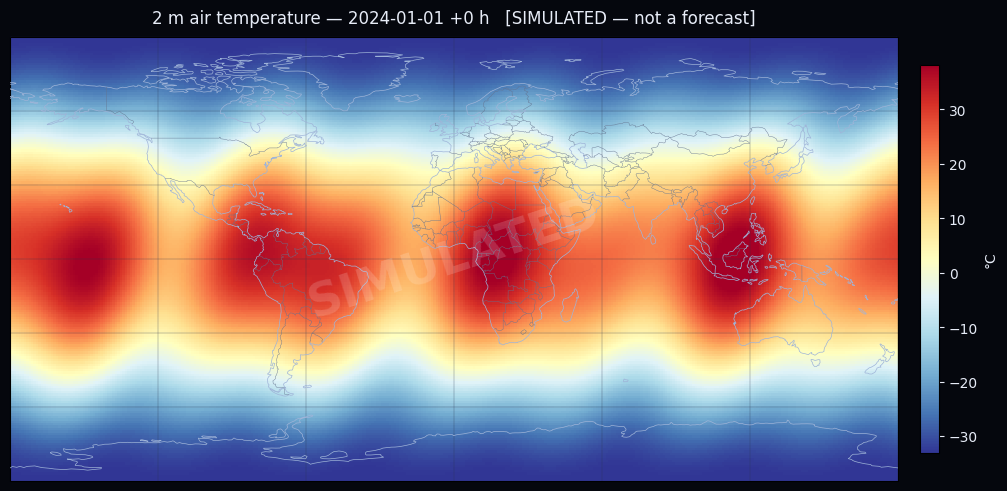

/home/user/earth_digital_twin/.venv/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


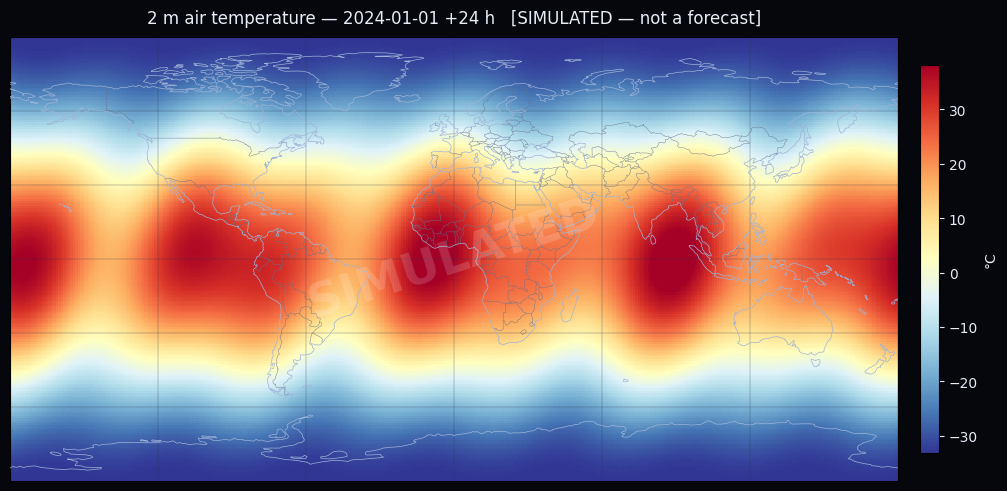

In [7]:
# --- Step 6b · plot the forecast ------------------------------------------
lats, lons = forecast["lat"][:], forecast["lon"][:]
tag = getattr(forecast, "sim_tag", None)   # None on a GPU: this is a real forecast
NOTE = {None: "", "SIMULATED": "   [SIMULATED — not a forecast]",
        "PERSISTENCE": "   [real GFS data, persisted — not a forecast]"}

for step in (0, NSTEPS):
    field = np.asarray(forecast["t2m"][0, step]) - 273.15  # kelvin -> celsius
    plot_field(
        field,
        lats,
        lons,
        title=f"2 m air temperature — {FORECAST_DATE} +{step * STEP_HOURS} h" + NOTE[tag],
        units="°C",
        cmap="RdYlBu_r",
        watermark=tag,
    )

**What you should see.** Two global maps of near-surface temperature: the initial condition, and the
state `NSTEPS × 6 h` later. On the GPU the difference between them is a real 24-hour AI forecast — warm
tropics, cold poles, weather systems having moved east overnight. In `cpu` mode both frames are real
GFS analysis, identical to each other, stamped `PERSISTENCE` — persistence really does predict that
nothing changes. In `dry` mode you get a smooth banded pattern stamped `SIMULATED`, whose waves shift
between the two frames because that's what the stand-in was built to do.

If you're on the hub, run `nvidia-smi` in a terminal *while* the cell above is executing and you'll see
memory in use. That's the second half of the acceptance test.

---

## Step 7 · Bringing in TEMPO

So far this is stock NVIDIA. Now the Smithsonian part.

**TEMPO** — Tropospheric Emissions: Monitoring of Pollution — is NASA's geostationary air-quality
instrument, with its science lead at **SAO** (PI Kelly Chance). Unlike a polar orbiter that sees a
given city once a day, TEMPO stares at North America continuously and re-scans roughly **every hour**
during daylight, sweeping east to west. It measures NO₂, ozone, formaldehyde, aerosols and
solar-induced chlorophyll fluorescence.

Two things about TEMPO data that trip people up, and that we handle below:

- **Its time dimension is sub-daily.** A single timestamp is a *longitude strip*, not a full disc.
  Ask a tile service like [NASA GIBS](https://nasa-gibs.github.io/gibs-api-docs/) for a bare date with
  no time and you'll get an empty tile back, which looks a lot like "the instrument is broken".
- **Its footprint is North America only.** Everything outside roughly 15–70° N, 20–170° W is nodata.
  That gap is not a bug — for the LEDT it's precisely the thing that motivates fusing TEMPO with
  MethaneSAT and DestinE in Year 2, so that STRI's tropical sites are covered too.

### Where the data comes from here

The loader below tries three sources in order, so it works everywhere:

1. **A pre-cached local file** — on the workshop hub, TEMPO granules are staged on disk so forty
   people don't hammer the archive at once. Set `LEDT_TEMPO_FILE` to point at one.
2. **NASA Earthdata via `earthaccess`** — the real thing, needs a free
   [Earthdata login](https://urs.earthdata.nasa.gov/). Only attempted if you already have credentials
   configured, so nobody gets an unexpected password prompt mid-workshop.
3. **A synthetic TEMPO-shaped field** — plausible urban NO₂ plumes over North American metros.
   Clearly labelled everywhere it's used. **Not measurement data.**

In [8]:
# --- Step 7 · load a TEMPO NO2 field --------------------------------------
from pathlib import Path

import xarray as xr

TEMPO_DATE = "2024-08-15"


def _synthetic_tempo(date=TEMPO_DATE):
    """A TEMPO-SHAPED MOCK. Not measurement data. Offline fallback only."""
    lon = np.linspace(-125, -65, 480)
    lat = np.linspace(15, 55, 320)
    LON, LAT = np.meshgrid(lon, lat)

    rng = np.random.default_rng(42)
    # A smooth continental background, brightest across the industrial midlatitudes.
    field = (
        0.35e15
        + 0.45e15 * np.exp(-((LAT - 39) ** 2) / 260)
        + 0.15e15 * np.sin(LON / 7.0) * np.cos(LAT / 11.0)
        + 0.04e15 * rng.normal(size=LON.shape)
    )
    metros = [  # (lat, lon, peak column) — roughly the usual suspects
        (40.71, -74.01, 8.0e15), (34.05, -118.24, 6.5e15), (29.76, -95.37, 5.5e15),
        (41.88, -87.63, 5.0e15), (33.75, -84.39, 4.0e15), (38.90, -77.04, 4.0e15),
        (25.76, -80.19, 3.0e15), (32.72, -117.16, 3.5e15), (39.95, -75.17, 4.5e15),
    ]
    for mlat, mlon, peak in metros:
        field += peak * np.exp(-((LAT - mlat) ** 2 + (LON - mlon) ** 2) / 0.35)

    return xr.Dataset(
        {"no2_troposphere": (("lat", "lon"), np.clip(field, 0, None).astype(np.float32),
                             {"units": "molec cm-2",
                              "provenance": "SYNTHETIC — not a TEMPO measurement"})},
        coords={"lat": lat, "lon": lon},
        attrs={"title": "Synthetic TEMPO-like NO2", "time_reference": date},
    )


def _normalize(ds):
    """Collapse whatever we loaded into a plain no2_troposphere(lat, lon) field."""
    names = ["no2_troposphere", "vertical_column_troposphere",
             "nitrogendioxide_tropospheric_column"]
    var = next((v for v in names if v in ds.data_vars), None)
    if var is None:
        raise ValueError(f"no NO2 variable found in {list(ds.data_vars)}")
    da = ds[var]
    renames = {n: t for n, t in (("latitude", "lat"), ("longitude", "lon")) if n in da.dims}
    if renames:
        da = da.rename(renames)
    da = da.squeeze(drop=True)
    return xr.Dataset({"no2_troposphere": da})


def load_tempo():
    """Return (dataset, provenance_string). Never raises."""
    # 1 · pre-cached file (the workshop hub stages one here)
    cached = os.environ.get("LEDT_TEMPO_FILE")
    candidates = [Path(cached)] if cached else []
    candidates += sorted(Path("data/tempo").glob("*.nc")) + sorted(Path.home().glob("data/tempo/*.nc"))
    for path in candidates:
        if path.exists():
            for group in ("product", None):
                try:
                    return _normalize(xr.open_dataset(path, group=group)), f"local file {path}"
                except Exception:
                    continue

    # 2 · NASA Earthdata, but only if credentials already exist
    has_creds = (Path.home() / ".netrc").exists() or "EARTHDATA_USERNAME" in os.environ
    if has_creds and have("earthaccess"):
        try:
            import earthaccess

            earthaccess.login(strategy="netrc", persist=True)
            hits = earthaccess.search_data(
                short_name="TEMPO_NO2_L3", temporal=(TEMPO_DATE, TEMPO_DATE), count=1
            )
            if hits:
                files = earthaccess.download(hits, local_path="data/tempo")
                return _normalize(xr.open_dataset(files[0], group="product")), \
                    f"NASA Earthdata ({Path(files[0]).name})"
        except Exception as exc:
            print(f"(earthaccess unavailable: {type(exc).__name__}: {exc})")

    # 3 · synthetic
    return _synthetic_tempo(), "SYNTHETIC — not measurement data"


tempo, tempo_source = load_tempo()
TEMPO_IS_REAL = not tempo_source.startswith("SYNTHETIC")
print(f"TEMPO source: {tempo_source}")
tempo

TEMPO source: SYNTHETIC — not measurement data


<xarray.Dataset> Size: 621kB
Dimensions:          (lat: 320, lon: 480)
Coordinates:
  * lat              (lat) float64 3kB 15.0 15.13 15.25 ... 54.75 54.87 55.0
  * lon              (lon) float64 4kB -125.0 -124.9 -124.7 ... -65.13 -65.0
Data variables:
    no2_troposphere  (lat, lon) float32 614kB 4.371e+14 3.836e+14 ... 4.827e+14
Attributes:
    title:           Synthetic TEMPO-like NO2
    time_reference:  2024-08-15

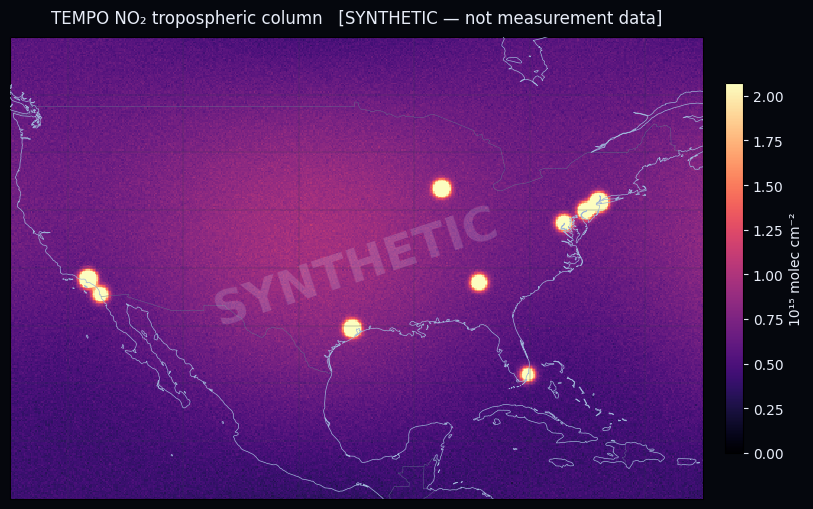

In [9]:
# --- Step 7b · plot the TEMPO field ---------------------------------------
# Columns are ~10^15 molecules per square centimetre, so plot in those units.
# NO2 is heavily skewed — a few urban pixels are 10x the continental background —
# so clip the colour scale at the 99.5th percentile or the plumes eat the map.
no2_scaled = tempo["no2_troposphere"].values / 1e15
plot_field(
    no2_scaled,
    tempo["lat"].values,
    tempo["lon"].values,
    title="TEMPO NO₂ tropospheric column"
          + ("" if TEMPO_IS_REAL else "   [SYNTHETIC — not measurement data]"),
    units="10¹⁵ molec cm⁻²",
    cmap="magma",
    extent=[-125, -65, 15, 55],
    vmin=0,
    vmax=np.nanpercentile(no2_scaled, 99.5),
    watermark=None if TEMPO_IS_REAL else "SYNTHETIC",
)

**What you should see.** North America with bright spots where the people are — the I-95 corridor, the
LA basin, Houston, Chicago. With real TEMPO data you'll also see the scan-strip edges and large nodata
regions (cloud, night, off-disc). With the synthetic field you get clean Gaussian blobs and a
`SYNTHETIC` stamp; a real granule is much messier, and that messiness is most of the actual work.

---

## Step 8 · Write your own diagnostic model

This is the heart of the tutorial. If you take one thing away, take this.

To make something Earth2Studio can use, you write a class with **four methods**:

| Method | What it must do |
|---|---|
| `__init__` | Subclass `torch.nn.Module` and call `super().__init__()`. That's what gives you `.to(device)` for free. |
| `input_coords()` | Return the `OrderedDict` describing what you accept. |
| `output_coords(input_coords)` | Return the `OrderedDict` describing what you emit. Validate the input here. |
| `__call__(x, coords)` | Do the work. Return `(tensor, coords)`. |

That's it. There is no registry to sign up for, no base class you must inherit, no config file. If your
object has those methods, `run.diagnostic()` will accept it alongside NVIDIA's own models. Python
duck-typing, used well.

### The one we're writing

`TEMPONO2Diagnostic` takes an atmospheric state on the Earth-2 grid and returns **TEMPO NO₂
regridded onto that same grid**, with NaN outside TEMPO's field of view.

Be clear about what this is and isn't:

- It is a **data-fusion** diagnostic. It injects a real measurement into the model's coordinate system
  so downstream components can consume it as just another variable. It does not *predict* NO₂ — TEMPO
  measures NO₂, and pretending otherwise would be exactly the overclaim the LEDT proposal is careful
  to avoid.
- It ignores the input values entirely (it only uses the input's *shape*). A learned diagnostic — the
  thing we actually want to build — would not.
- The regridding is nearest-neighbour, which is fine for a demo and wrong for a flux budget. In
  production you'd use conservative regridding via [xESMF](https://xesmf.readthedocs.io/) or
  [pyresample](https://pyresample.readthedocs.io/).

### About the two decorators

Real Earth2Studio code decorates these methods with `@batch_coords()` and `@batch_func()`, which
handle the leading `batch` dimension for you, and calls `handshake_dim` / `handshake_coords` to
validate inputs. So that the class below is *literally the same code* you'd write with earth2studio
installed, the next cell imports them if it can and defines do-nothing stand-ins if it can't.

In [10]:
# --- Step 8 · imports, with laptop stand-ins ------------------------------
import torch

try:
    from earth2studio.models.batch import batch_coords, batch_func
    from earth2studio.utils import handshake_coords, handshake_dim

    USING_REAL_DECORATORS = True
except ImportError:
    USING_REAL_DECORATORS = False

    def _passthrough():
        """Stand-in for @batch_coords() / @batch_func(): a no-op decorator."""
        def decorator(fn):
            return fn
        return decorator

    batch_coords = batch_func = _passthrough

    def handshake_dim(coords, key, index=None):
        """Stand-in: the real one checks `key` is dimension `index` of `coords`."""

    def handshake_coords(coords, target, key):
        """Stand-in: the real one checks coords[key] matches target[key] exactly."""


print("using the real earth2studio decorators:", USING_REAL_DECORATORS)

using the real earth2studio decorators: False


In [11]:
# --- Step 8b · the diagnostic model ---------------------------------------
class TEMPONO2Diagnostic(torch.nn.Module):
    """Inject TEMPO NO2 into an Earth-2 pipeline as a diagnostic variable.

    This is a *data fusion* layer, not a predictive model: TEMPO measures NO2,
    and this class puts that measurement onto the prognostic model's grid so
    downstream components can consume it like any other field. Outside TEMPO's
    North-American field of view the output is NaN.

    Parameters
    ----------
    tempo_ds : xr.Dataset
        Dataset with a no2_troposphere(lat, lon) variable, lon in -180..180.
    lat, lon : np.ndarray
        The target grid — use the coords of whatever prognostic you're pairing
        with. Defaults to the FourCastNet 720 x 1440 grid.
    input_var : str
        Which variable this diagnostic declares as its input. It is not used in
        the computation; it only has to be something the prognostic produces.
    """

    def __init__(self, tempo_ds, lat=None, lon=None, input_var="t2m"):
        super().__init__()
        self._lat = E2_LAT if lat is None else np.asarray(lat)
        self._lon = E2_LON if lon is None else np.asarray(lon)
        self._input_var = input_var

        # Regrid once, at construction time, and keep it as a buffer so that
        # .to(device) moves it to the GPU along with everything else.
        self.register_buffer(
            "no2", torch.from_numpy(self._regrid(tempo_ds)), persistent=False
        )

    # -- the Earth2Studio contract ----------------------------------------
    def input_coords(self):
        return OrderedDict(
            {
                "batch": np.empty(0),
                "variable": np.array([self._input_var]),
                "lat": self._lat,
                "lon": self._lon,
            }
        )

    @batch_coords()
    def output_coords(self, input_coords):
        # Validate: right dimensions, in the right order, on the right grid.
        target = self.input_coords()
        for i, key in enumerate(target):
            if key != "batch":
                handshake_dim(input_coords, key, i)
                handshake_coords(input_coords, target, key)

        out = OrderedDict(
            {
                "batch": np.empty(0),
                "variable": np.array(["no2_troposphere"]),
                "lat": self._lat,
                "lon": self._lon,
            }
        )
        out["batch"] = input_coords["batch"]
        return out

    @batch_func()
    def __call__(self, x, coords):
        out_coords = self.output_coords(coords)
        # Broadcast the (lat, lon) TEMPO field across the input's batch dim.
        out = self.no2.to(x.device).expand(x.shape[0], 1, *self.no2.shape).clone()
        return out, out_coords

    # -- helper ------------------------------------------------------------
    def _regrid(self, ds):
        """Nearest-neighbour TEMPO grid -> target grid. NaN outside the FOV.

        Fine for a demo. For anything quantitative use a conservative regrid
        (xESMF / pyresample) so you don't silently break mass conservation.
        """
        t_lat = ds["lat"].values
        t_lon = ds["lon"].values
        t_lon360 = np.where(t_lon < 0, t_lon + 360, t_lon)   # TEMPO is -180..180, Earth-2 is 0..360
        values = ds["no2_troposphere"].values

        out = np.full((self._lat.size, self._lon.size), np.nan, dtype=np.float32)
        lat_in = (self._lat >= t_lat.min()) & (self._lat <= t_lat.max())
        lon_in = (self._lon >= t_lon360.min()) & (self._lon <= t_lon360.max())

        i = np.abs(self._lat[lat_in][:, None] - t_lat[None, :]).argmin(axis=1)
        j = np.abs(self._lon[lon_in][:, None] - t_lon360[None, :]).argmin(axis=1)
        out[np.ix_(lat_in, lon_in)] = values[np.ix_(i, j)]
        return out


tempo_dx = TEMPONO2Diagnostic(tempo)

print("input_coords :")
for k, v in tempo_dx.input_coords().items():
    print(f"   {k:<9} {v.shape}  {v[:3] if v.size else '(any)'}")
print("output_coords:")
for k, v in tempo_dx.output_coords(tempo_dx.input_coords()).items():
    print(f"   {k:<9} {v.shape}  {v[:3] if v.size else '(any)'}")

input_coords :
   batch     (0,)  (any)
   variable  (1,)  ['t2m']
   lat       (720,)  [90.   89.75 89.5 ]
   lon       (1440,)  [0.   0.25 0.5 ]
output_coords:
   batch     (0,)  (any)
   variable  (1,)  ['no2_troposphere']
   lat       (720,)  [90.   89.75 89.5 ]
   lon       (1440,)  [0.   0.25 0.5 ]


### Test it before you trust it

A model with the right method names but the wrong shapes will fail deep inside a workflow, with an
unhelpful error. Two minutes of testing up front saves a lot of that. Feed it a dummy tensor and check
what comes back — this runs on CPU everywhere, no GPU required.

In [12]:
# --- Step 8c · smoke-test the diagnostic ----------------------------------
coords = tempo_dx.input_coords()
coords["batch"] = np.array([0])                     # one batch member
dummy = torch.zeros(1, 1, E2_LAT.size, E2_LON.size)  # (batch, variable, lat, lon)

no2_out, no2_coords = tempo_dx(dummy, coords)

inside = ~torch.isnan(no2_out)
print(f"output shape     {tuple(no2_out.shape)}")
print(f"output variable  {no2_coords['variable']}")
print(f"NaN fraction     {float(torch.isnan(no2_out).float().mean()):.1%}  (everything outside TEMPO's FOV)")
print(f"inside the FOV   {no2_out[inside].min():.2e} – {no2_out[inside].max():.2e} molec cm⁻²")

assert no2_out.shape == (1, 1, E2_LAT.size, E2_LON.size), "unexpected output shape"
assert inside.any(), "the whole field is NaN — check the lon convention (0..360 vs -180..180)"
print("\n✅ the diagnostic behaves")

output shape     (1, 1, 720, 1440)
output variable  ['no2_troposphere']
NaN fraction     96.3%  (everything outside TEMPO's FOV)
inside the FOV   2.76e+14 – 8.65e+15 molec cm⁻²

✅ the diagnostic behaves


/home/user/earth_digital_twin/.venv/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


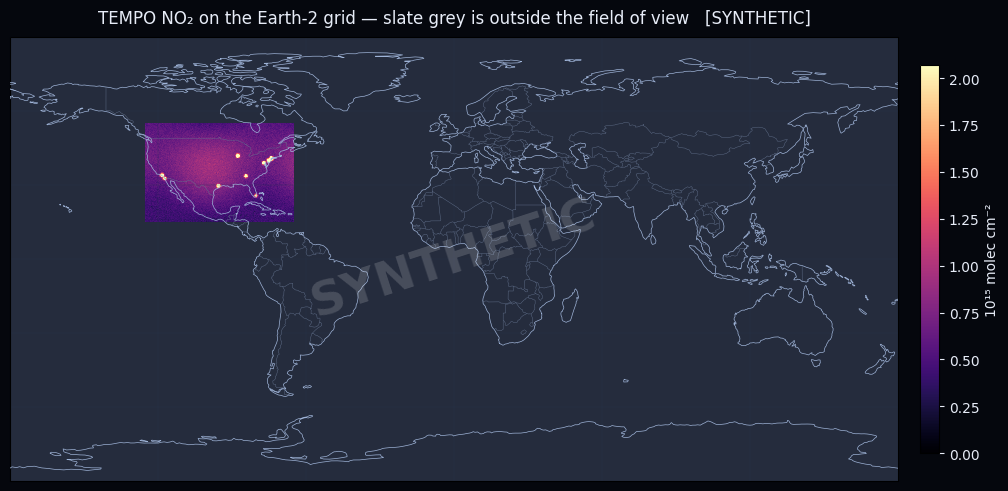

In [13]:
# --- Step 8d · see it on the global grid ----------------------------------
plot_field(
    no2_out[0, 0].numpy() / 1e15,
    E2_LAT,
    E2_LON,
    title="TEMPO NO₂ on the Earth-2 grid — slate grey is outside the field of view"
          + ("" if TEMPO_IS_REAL else "   [SYNTHETIC]"),
    units="10¹⁵ molec cm⁻²",
    cmap="magma",
    vmin=0,
    vmax=np.nanpercentile(no2_scaled, 99.5),
    watermark=None if TEMPO_IS_REAL else "SYNTHETIC",
)

**What you should see.** A global map that is slate grey — no data — everywhere except a
North-American patch. The NaN fraction printed above should be somewhere around 96–99%.

That emptiness is the honest picture of the problem the LEDT is trying to solve: a geostationary
instrument gives you superb temporal resolution over one continent and nothing at all over the
tropics, where STRI's ForestGEO plots are. Filling in the rest is a fusion problem, not a TEMPO
problem.

---

## Step 9 · Couple the diagnostic to the forecast

Now the payoff. Swapping `run.deterministic` for `run.diagnostic` inserts your model into the loop:
at every forecast step, the prognostic's output is handed to your diagnostic, and your diagnostic's
output is what gets written.

```python
io = run.diagnostic(
    [FORECAST_DATE],   # start time
    NSTEPS,            # how many steps
    prognostic,        # FCN — the AI weather model
    tempo_dx,          # your TEMPO diagnostic
    GFS(),             # initial condition
    ZarrBackend(),     # where output goes
)
```

Note what you *didn't* have to do. You didn't register anything, subclass anything, or edit any NVIDIA
code. Your class satisfies the interface, so it is a first-class citizen of the pipeline — identical
standing to `PrecipitationAFNO` or `CorrDiff`.

Under the hood, `run.diagnostic` calls `map_coords(x, coords, diagnostic.input_coords())` before
handing data over. That's what lets your diagnostic declare `variable=["t2m"]` and receive only that
slice out of FourCastNet's 26 variables — the coordinate contract from Step 4 doing real work.

The cell below runs it for real in `gpu` mode. In `cpu`/`dry` mode it prints the call you would have
made and applies the diagnostic to the forecast we already have, step by step, on the CPU — which is
what `run.diagnostic` does internally anyway, minus the machinery.

In [14]:
# --- Step 9 · run the coupled pipeline ------------------------------------
CALL = f"""io = run.diagnostic(
    ["{FORECAST_DATE}"], {NSTEPS}, prognostic, tempo_dx, GFS(), ZarrBackend()
)"""

if MODE == "gpu":
    try:
        from earth2studio.data import GFS
        from earth2studio.io import ZarrBackend
        from earth2studio.models.px import FCN
        import earth2studio.run as run

        prognostic = FCN.load_model(FCN.load_default_package())
        coupled = run.diagnostic(
            [FORECAST_DATE], NSTEPS, prognostic, tempo_dx, GFS(), ZarrBackend()
        )
        print(coupled.root.tree())
        coupled_no2 = np.asarray(coupled["no2_troposphere"][0, -1])
        print("\n✅ coupled run complete — output written by the IO backend")
    except Exception as exc:
        print(f"⚠️  coupled run failed ({type(exc).__name__}: {exc}); "
              "falling back to the local path")
        coupled_no2 = no2_out[0, 0].numpy()
else:
    print("On a GPU this cell would run:\n")
    print(CALL)
    print("\nWithout one, here is the same thing done by hand — the diagnostic")
    print("applied at each forecast step, which is what run.diagnostic does internally:\n")

    frames = []
    for step in range(NSTEPS + 1):
        state = torch.zeros(1, 1, E2_LAT.size, E2_LON.size)  # stands in for the prognostic output
        step_coords = tempo_dx.input_coords()
        step_coords["batch"] = np.array([0])
        out, _ = tempo_dx(state, step_coords)
        frames.append(out[0, 0].numpy())
        print(f"   step {step}  (+{step * STEP_HOURS:>2} h)  →  no2_troposphere "
              f"{tuple(out.shape[-2:])}")
    coupled_no2 = frames[-1]

print(f"\nfinal NO₂ field: {coupled_no2.shape}, "
      f"{np.isnan(coupled_no2).mean():.1%} NaN outside the FOV")

On a GPU this cell would run:

io = run.diagnostic(
    ["2024-01-01"], 4, prognostic, tempo_dx, GFS(), ZarrBackend()
)

Without one, here is the same thing done by hand — the diagnostic
applied at each forecast step, which is what run.diagnostic does internally:

   step 0  (+ 0 h)  →  no2_troposphere (720, 1440)
   step 1  (+ 6 h)  →  no2_troposphere (720, 1440)
   step 2  (+12 h)  →  no2_troposphere (720, 1440)
   step 3  (+18 h)  →  no2_troposphere (720, 1440)
   step 4  (+24 h)  →  no2_troposphere (720, 1440)

final NO₂ field: (720, 1440), 96.3% NaN outside the FOV


> **Why is the NO₂ field the same at every step?** Because this diagnostic is a static injection of one
> TEMPO scan — it ignores the atmospheric state it's given. That's the honest thing for a data-fusion
> layer to do, and it's also the seam where the interesting work starts. A diagnostic that *did* use
> the incoming state — TEMPO chemistry plus modelled meteorology in, ecosystem response out — is
> exactly what we're convening in September to design.

---

## Step 10 · Down to the field sites

The last link in the chain: from a global grid to the places where Smithsonian scientists actually
have instruments in the ground — SERC's tidal wetlands on the Chesapeake, STRI's forest plots in
Panama.

> ### ⚠️ Read this before reading the numbers
>
> **The response model below is a toy and is not science.** It is a made-up linear sensitivity
> coefficient per biome, invented so that the pipeline has an endpoint. The real thing will be a
> learned operator trained on TEMPO chemistry against decades of GCReW eddy-covariance flux, ForestGEO
> census data and Coastal Carbon Network observations — and building it is the point of the workshop.
> Please don't screenshot this table.

In [15]:
# --- Step 10 · sample at the field network --------------------------------
# Representative SERC / STRI sites (the same ones on livingearthtwin.org).
FIELD_SITES = {
    "GCReW (SERC, tidal wetland)":    (38.8743, -76.5509, "wetland"),
    "Kirkpatrick Marsh (SERC)":       (38.8740, -76.5460, "wetland"),
    "Barro Colorado Island (STRI)":   (9.1521, -79.8465, "forest"),
    "Agua Salud (STRI)":              (9.2167, -79.7333, "forest"),
    "Bocas del Toro mangrove (STRI)": (9.3500, -82.2500, "mangrove"),
}

# TOY sensitivities. Invented. Placeholders for a trained model.
TOY_SENSITIVITY = {"wetland": -0.12, "forest": -0.35, "mangrove": -0.08}


def sample(field, lat, lon):
    """Nearest-cell value of `field` on (E2_LAT, E2_LON) at a site."""
    i = int(np.abs(E2_LAT - lat).argmin())
    j = int(np.abs(E2_LON - (lon % 360)).argmin())
    return float(field[i, j])


scale = np.nanpercentile(coupled_no2, 99)
print(f"{'Site':<34}{'biome':<10}{'NO2 column':>14}{'toy response':>15}")
print("-" * 73)
for name, (lat, lon, biome) in FIELD_SITES.items():
    value = sample(coupled_no2, lat, lon)
    if np.isnan(value):
        print(f"{name:<34}{biome:<10}{'outside FOV':>14}{'—':>15}")
    else:
        response = TOY_SENSITIVITY[biome] * value / scale
        print(f"{name:<34}{biome:<10}{value:>14.2e}{response:>+15.3f}")

print("\nThe STRI sites report 'outside FOV' because TEMPO is a North-America")
print("instrument. That gap is the argument for TEMPO + MethaneSAT + DestinE")
print("fusion in Year 2 of the proposal — not a defect in the code.")

Site                              biome         NO2 column   toy response
-------------------------------------------------------------------------
GCReW (SERC, tidal wetland)       wetland         2.33e+15         -0.260
Kirkpatrick Marsh (SERC)          wetland         2.33e+15         -0.260
Barro Colorado Island (STRI)      forest       outside FOV              —
Agua Salud (STRI)                 forest       outside FOV              —
Bocas del Toro mangrove (STRI)    mangrove     outside FOV              —

The STRI sites report 'outside FOV' because TEMPO is a North-America
instrument. That gap is the argument for TEMPO + MethaneSAT + DestinE
fusion in Year 2 of the proposal — not a defect in the code.


---

## Step 11 · Getting your results out

Whatever you build at the workshop, you'll want to take it home. Earth2Studio writes through an **IO
backend**, and the two you'll use most are:

```python
from earth2studio.io import ZarrBackend, NetCDF4Backend

io = ZarrBackend()                              # in memory (default)
io = ZarrBackend(file_name="outputs/run.zarr")  # on disk
io = NetCDF4Backend(file_name="outputs/run.nc") # if you'd rather have NetCDF
```

A Zarr store on disk reads straight back into xarray with `xr.open_zarr("outputs/run.zarr")`, which
means everything you already know about xarray, dask and matplotlib applies unchanged.

> **On the workshop hub, assume your session is ephemeral.** Write results to your home directory or
> download them through the JupyterLab file browser before you log out. Don't leave anything you care
> about only in a container.

In [16]:
# --- Step 11 · save what we made ------------------------------------------
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

result = xr.Dataset(
    {"no2_troposphere": (("lat", "lon"), coupled_no2.astype("float32"),
                         {"units": "molec cm-2",
                          "long_name": "TEMPO NO2 tropospheric column on the Earth-2 grid"})},
    coords={"lat": E2_LAT, "lon": E2_LON},
    attrs={
        "title": "LEDT tutorial output",
        "tempo_source": tempo_source,
        "earth2studio_mode": MODE,
        "note": "Tutorial artifact. The ecological response model is a toy; do not use for science.",
    },
)

path = OUT / "ledt_tutorial_no2.nc"
result.to_netcdf(path)
print(f"wrote {path}  ({path.stat().st_size / 1e6:.1f} MB)")
print("\nread it back with:  xr.open_dataset('outputs/ledt_tutorial_no2.nc')")
result

wrote outputs/ledt_tutorial_no2.nc  (4.2 MB)

read it back with:  xr.open_dataset('outputs/ledt_tutorial_no2.nc')


<xarray.Dataset> Size: 4MB
Dimensions:          (lat: 720, lon: 1440)
Coordinates:
  * lat              (lat) float64 6kB 90.0 89.75 89.5 ... -89.25 -89.5 -89.75
  * lon              (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    no2_troposphere  (lat, lon) float32 4MB nan nan nan nan ... nan nan nan nan
Attributes:
    title:              LEDT tutorial output
    tempo_source:       SYNTHETIC — not measurement data
    earth2studio_mode:  dry
    note:               Tutorial artifact. The ecological response model is a...

---

## Step 12 · Where to go next

You now know the whole shape of Earth2Studio. Some things to try, roughly in order of how much they'll
teach you per hour spent:

1. **Change the forecast length.** Set `NSTEPS = 20` (5 days) and re-run Step 6. Watch where it starts
   to lose skill.
2. **Swap the model.** Replace `FCN` with `SFNO`, `DLWP` or `GraphCastSmall`. Remember the grid
   changes — `SFNO` is 721 latitudes, not 720 — so pass the right `lat`/`lon` into
   `TEMPONO2Diagnostic`. Getting this wrong, and seeing the error Earth2Studio gives you, is a
   genuinely useful five minutes.
3. **Use a built-in diagnostic.** `PrecipitationAFNO` in place of `tempo_dx`, and you have a
   precipitation forecast.
4. **Run an ensemble.** `run.ensemble` with a perturbation method from `earth2studio.perturbation`.
   This is where the GPU really starts to matter.
5. **Make the diagnostic actually use its input.** Right now `__call__` ignores `x`. Have it combine
   TEMPO NO₂ with the incoming temperature or humidity field. Now you have something that varies with
   forecast lead time — and you're a short distance from the thing the LEDT is actually proposing.

### Cheat sheet

```python
from earth2studio.data   import GFS, ARCO, HRRR, IFS       # initial conditions
from earth2studio.models.px import FCN, SFNO, DLWP, Aurora  # forecast models
from earth2studio.models.dx import PrecipitationAFNO, CorrDiff, ClimateNet
from earth2studio.io     import ZarrBackend, NetCDF4Backend
import earth2studio.run as run

run.deterministic(time, nsteps, prognostic, data, io)
run.diagnostic(time, nsteps, prognostic, diagnostic, data, io)
run.ensemble(time, nsteps, nensemble, prognostic, data, io, perturbation)
```

### Reading

- [Earth2Studio documentation](https://nvidia.github.io/earth2studio/) — start with the User Guide,
  then the Examples gallery
- [Earth2Studio on GitHub](https://github.com/NVIDIA/earth2studio) — the examples in `examples/` are
  the best documentation in the project
- [`examples/08_extend/`](https://github.com/NVIDIA/earth2studio/tree/main/examples/08_extend) —
  custom prognostics, diagnostics and data sources. Step 8 of this notebook follows
  `02_custom_diagnostic.py` closely.
- [TEMPO at SAO](https://tempo.si.edu) · [NASA GIBS](https://nasa-gibs.github.io/gibs-api-docs/) ·
  [SERC GCReW](https://serc.si.edu/gcrew) · [STRI ForestGEO](https://forestgeo.si.edu)
- [`notebooks/tempo_earth2_integration.ipynb`](tempo_earth2_integration.ipynb) — the companion
  notebook in this repo, which goes further into the TEMPO side.

### Bring a question to September

The workshop is a working sprint, not a lecture series. The most useful thing you can arrive with is a
concrete question from your own science that has this shape:

> *"If I could ask a planetary digital twin for **[some atmospheric quantity]** at **[my field site]**
> every hour, I could finally test **[some hypothesis]**."*

That sentence is the whole design brief. See you in Cambridge. 🌍

---

## Appendix A · Troubleshooting

| What you see | What it means | What to do |
|---|---|---|
| `ModuleNotFoundError: No module named 'earth2studio'` | Not installed. | Nothing — the notebook runs in `dry` mode. To install: `pip install "earth2studio[fcn,precip-afno,data]==0.17.0"` |
| `torch.cuda.is_available()` is `False` on the hub | The container didn't get the GPU. | Restart the kernel. If it persists, tell an organiser — this is a hub problem, not yours. |
| `CUDA out of memory` | The model is bigger than the GPU. | Restart the kernel (this frees the memory), reduce `NSTEPS`, or use a smaller model. Check what else is running with `nvidia-smi`. |
| Model download hangs or times out | NGC / Hugging Face is slow or blocked. | Retry; set `EARTH2STUDIO_PACKAGE_TIMEOUT` higher. On the hub the weights should already be cached. |
| `handshake_dim` / `handshake_coords` error | Your coordinates don't match the model's. | Print both `input_coords()` dicts and compare. Usually 720 vs 721 latitudes, or lon in −180…180 instead of 0…360. |
| The regridded TEMPO field is entirely NaN | Longitude convention mismatch. | TEMPO is −180…180, Earth-2 is 0…360. See `_regrid` in Step 8b. |
| `earthaccess` asks for a password | No cached Earthdata credentials. | Get a free login at [urs.earthdata.nasa.gov](https://urs.earthdata.nasa.gov/), or just let the notebook use its synthetic fallback. |
| A TEMPO tile request comes back empty for a valid date | TEMPO's time axis is sub-daily. | Ask GIBS for a full timestamp (`2024-08-15T18:00:00Z`) or the literal `default`, not a bare date. |
| Cells fail after a restart | Notebook state is gone. | *Run ▸ Run All Cells*. Everything here is cheap to re-run except the model download, which is cached. |

**Getting properly stuck is fine.** Grab an organiser, or open an issue on
[the LEDT repo](https://github.com/granttremblay/earth_digital_twin).

---

<div align="center">

**Smithsonian Living Earth Digital Twin** · OUSSR Innovation Concept seed award
PI Grant Tremblay (SAO) · [livingearthtwin.org](https://livingearthtwin.org)

*"Big things have small beginnings."*

</div>